In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv('Social_Network_Ads.csv')[['Age','EstimatedSalary','Purchased']]

In [32]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_8392\2855263893.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])
C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_8392\2855263893.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['EstimatedSalary'])


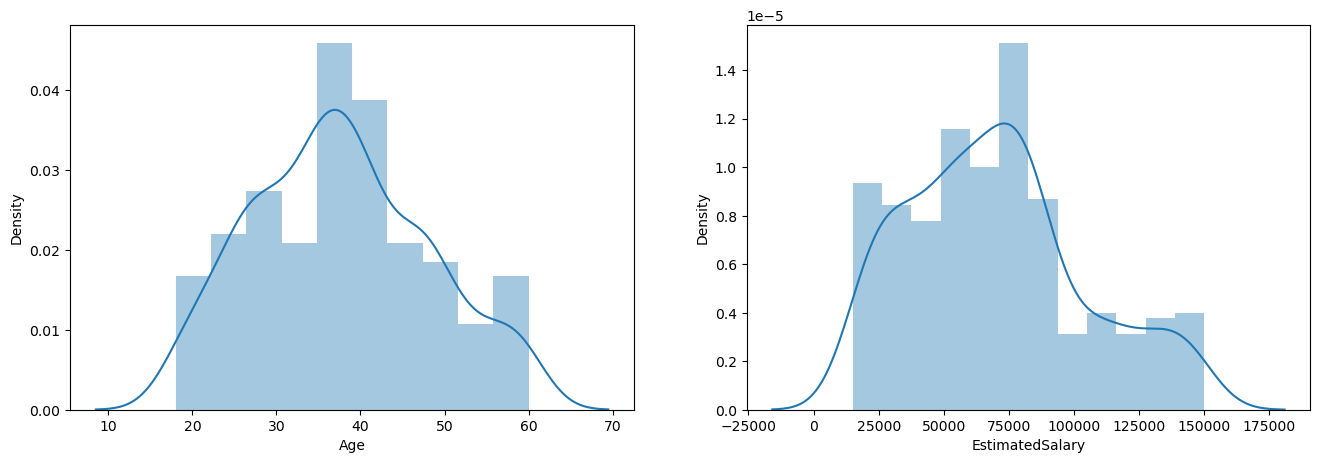

In [33]:
plt.figure(figsize=(16,5))

plt.subplot(1,2,1)
sns.distplot(df['Age'])

plt.subplot(1,2,2)
sns.distplot(df['EstimatedSalary'])

plt.show()

In [34]:
df['EstimatedSalary'].skew()

0.49502362888993623

In [35]:
df.loc[len(df)] = [7,170000,1]
df.loc[len(df)] = [67,185000,1]
df.loc[len(df)] = [9,190000,1]
df.loc[len(df)] = [60,160000,0]

In [48]:
df.shape

(404, 3)

<Axes: xlabel='EstimatedSalary'>

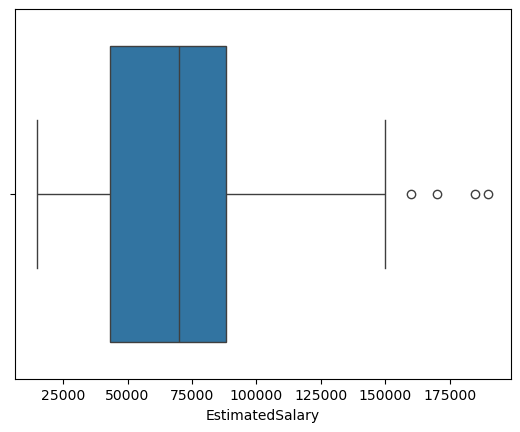

In [36]:
sns.boxplot(x=df['EstimatedSalary'])

In [37]:
# Finding the IQR
percentile25 = df['EstimatedSalary'].quantile(0.25)
percentile75 = df['EstimatedSalary'].quantile(0.75)

In [38]:
IQR = percentile75 - percentile25
IQR

45000.0

In [39]:
upperlimit = percentile75 + 1.5 * IQR
lowerlimit = percentile25 - 1.5 * IQR

In [40]:
upperlimit, lowerlimit

(155500.0, -24500.0)

In [41]:
# Finding Outliers
new_df = df[df['EstimatedSalary'] > upperlimit]  

In [42]:
df[df['EstimatedSalary'] < lowerlimit]  

,Age,EstimatedSalary,Purchased


In [49]:
# Trimmimg
new_df = df[df['EstimatedSalary'] < upperlimit] 
new_df.shape

(400, 3)

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_8392\1781517291.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['EstimatedSalary'])
C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_8392\1781517291.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['EstimatedSalary'])


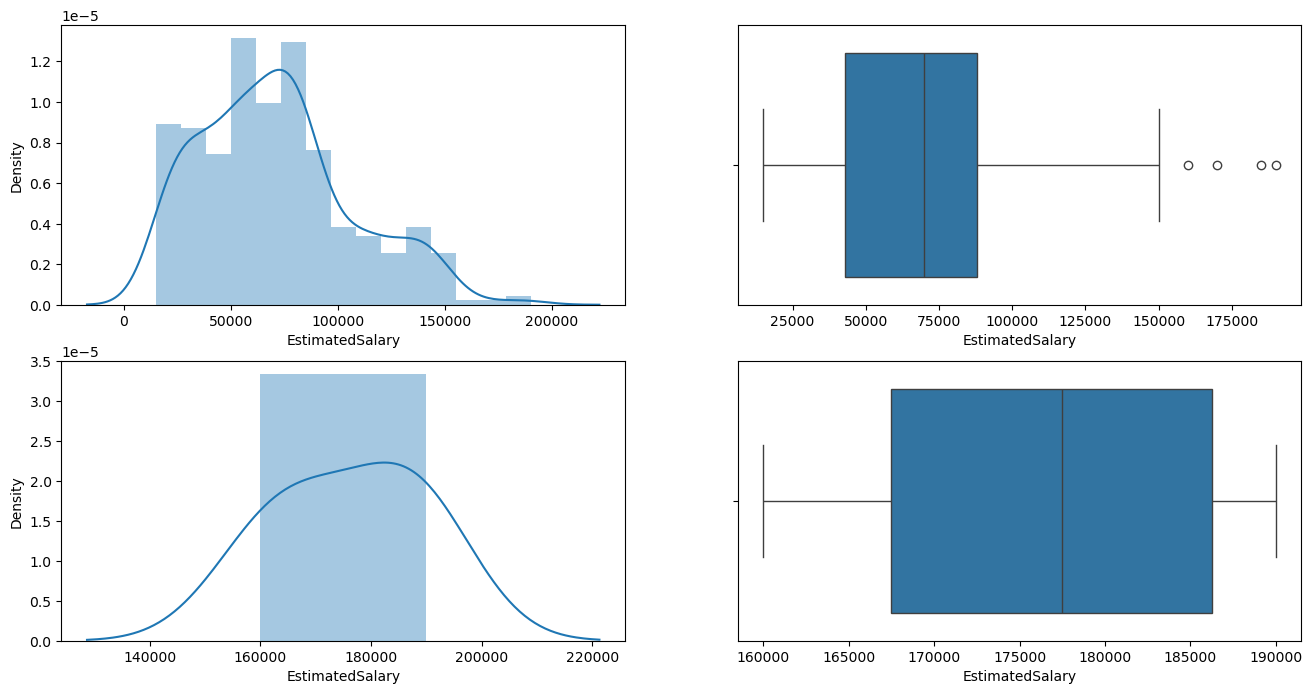

In [43]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['EstimatedSalary'])

plt.subplot(2,2,2)
sns.boxplot(x=df['EstimatedSalary'])

plt.subplot(2,2,3)
sns.distplot(new_df['EstimatedSalary'])

plt.subplot(2,2,4)
sns.boxplot(x=new_df['EstimatedSalary'])

plt.show()

In [46]:
# Capping

new_df2 = df.copy()

new_df2['EstimatedSalary'] = np.where(
    new_df2['EstimatedSalary'] < lowerlimit, lowerlimit,
    np.where(new_df2['EstimatedSalary'] > upperlimit, upperlimit, df['EstimatedSalary'])
)

In [47]:
new_df2.shape

(404, 3)

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_8392\2624053736.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['EstimatedSalary'])
C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_8392\2624053736.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df2['EstimatedSalary'])


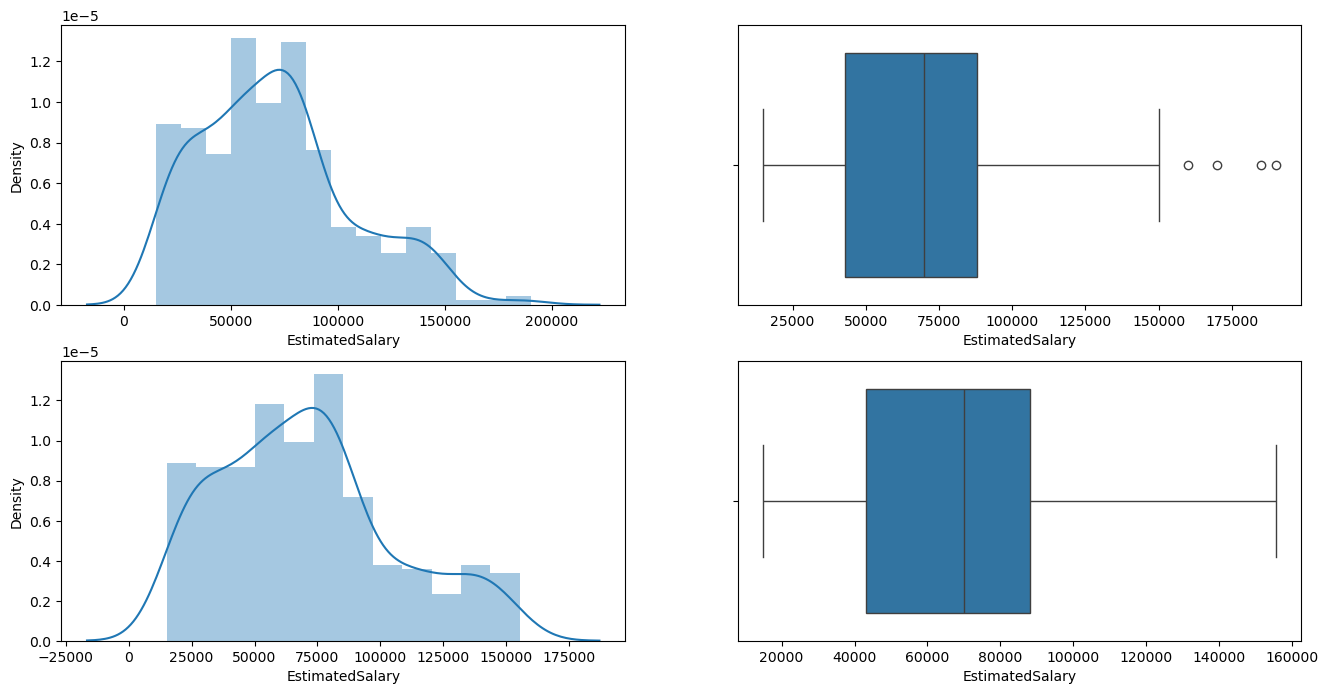

In [50]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['EstimatedSalary'])

plt.subplot(2,2,2)
sns.boxplot(x=df['EstimatedSalary'])

plt.subplot(2,2,3)
sns.distplot(new_df2['EstimatedSalary'])

plt.subplot(2,2,4)
sns.boxplot(x=new_df2['EstimatedSalary'])

plt.show()